### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

### Class Definitions

In [2]:
class Similarity():
    def __init__(self, path, perplexity = 5, n_components = 2):
        self.path = path
        self.perplexity = perplexity
        self.n_components = n_components
    
    def loadEmbeddings(self):
       checkpoint = torch.load(self.path, map_location='cpu')
       worker_embeddings = checkpoint['worker_embeddings.weight'].detach().cpu().numpy()
       return worker_embeddings

    def getSimilarity(self, worker_embeddings):
        return cosine_similarity(worker_embeddings, worker_embeddings)
    
    def getReducedEmbeddings(self, worker_embeddings):
        worker_embeds = []
        worker_ids = []

        for i in range(worker_embeddings.shape[0]):
            worker_embeds.append(worker_embeddings[i])
            worker_ids.append(i)


        tsne_model = TSNE(perplexity=self.perplexity, n_components=self.n_components, init='pca', n_iter=2500, random_state=23)
        new_values = tsne_model.fit_transform(np.array(worker_embeds))
        return (new_values, worker_ids)
    
    def main(self):
        worker_embeddings = self.loadEmbeddings()
        similarity = self.getSimilarity(worker_embeddings)
        reduced_embeds = self.getReducedEmbeddings(worker_embeddings)
        return(similarity, reduced_embeds[0], reduced_embeds[1])

In [3]:
class Plotting():
    def __init__(self, similarity, reduced_embeds, worker_ids):
        self.similarity = similarity
        self.reduced_embeds = reduced_embeds
        self.worker_ids = worker_ids
    
    def plotCM(self):
        fig, ax = plt.subplots(figsize=(20,20))
        sns.heatmap(self.similarity, cmap='hot', annot = True, fmt = ".2f", ax = ax, linewidths=1, square=True)
    
    def plotSim(self):
        x = []
        y = []
        for value in self.reduced_embeds:
            x.append(value[0])
            y.append(value[1])
            
        plt.figure(figsize=(8, 8)) 
        for i in range(len(x)):
            plt.scatter(x[i],y[i])
            plt.annotate(self.worker_ids[i], xy=(x[i], y[i]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
        plt.show()
    
    def main(self):
        self.plotCM()
        self.plotSim()

### Main Code
- Epoch = 1
- Embed size = 8
- Workers = 21

/users/student/pg/pg24/abhishek/.conda/envs/rnd/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


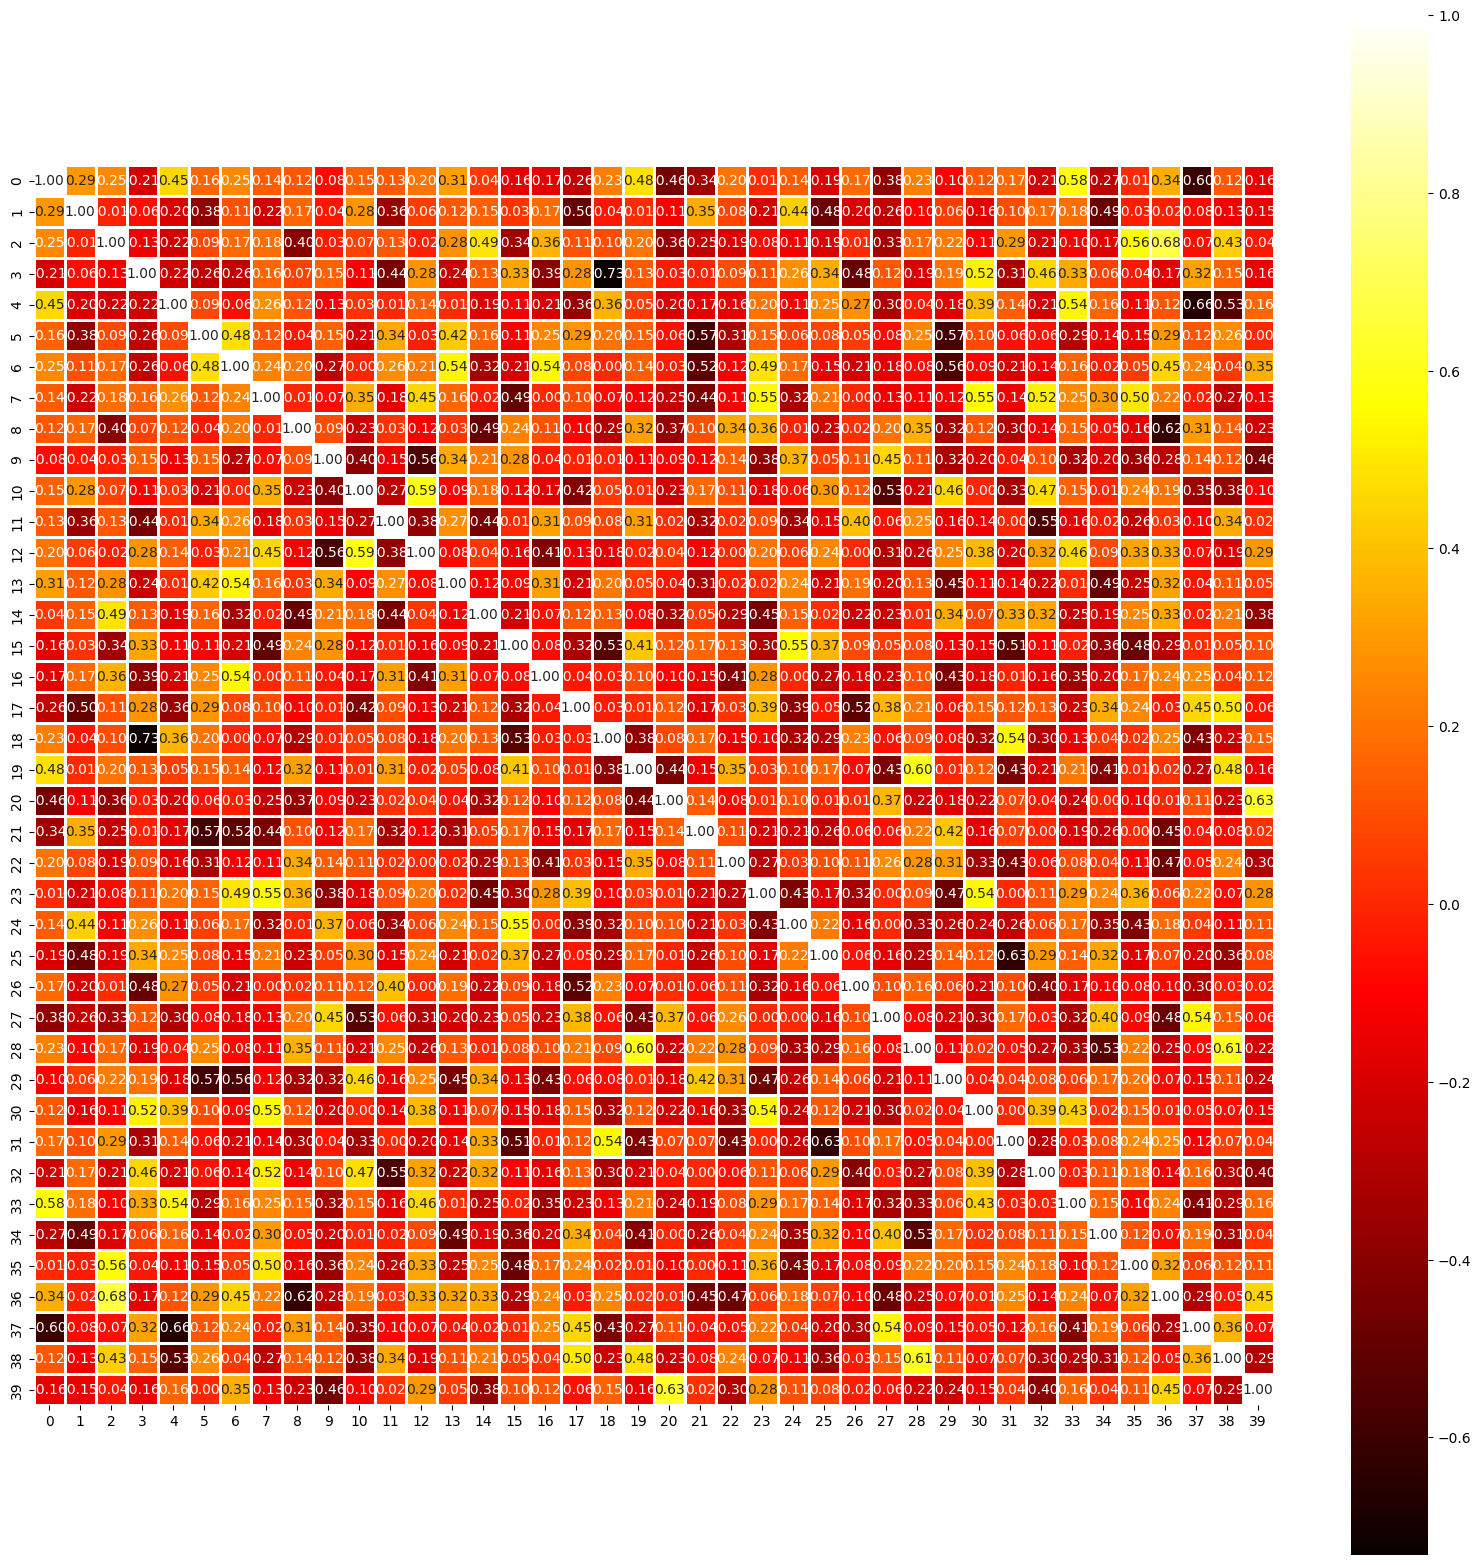

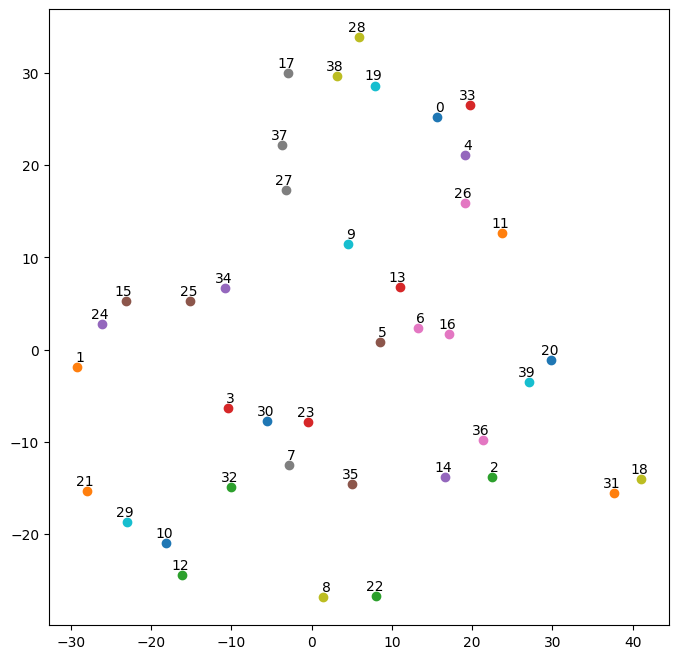

In [6]:
path = '/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin'
s = Similarity(path, 5, 2)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()

/users/student/pg/pg24/abhishek/.conda/envs/rnd/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


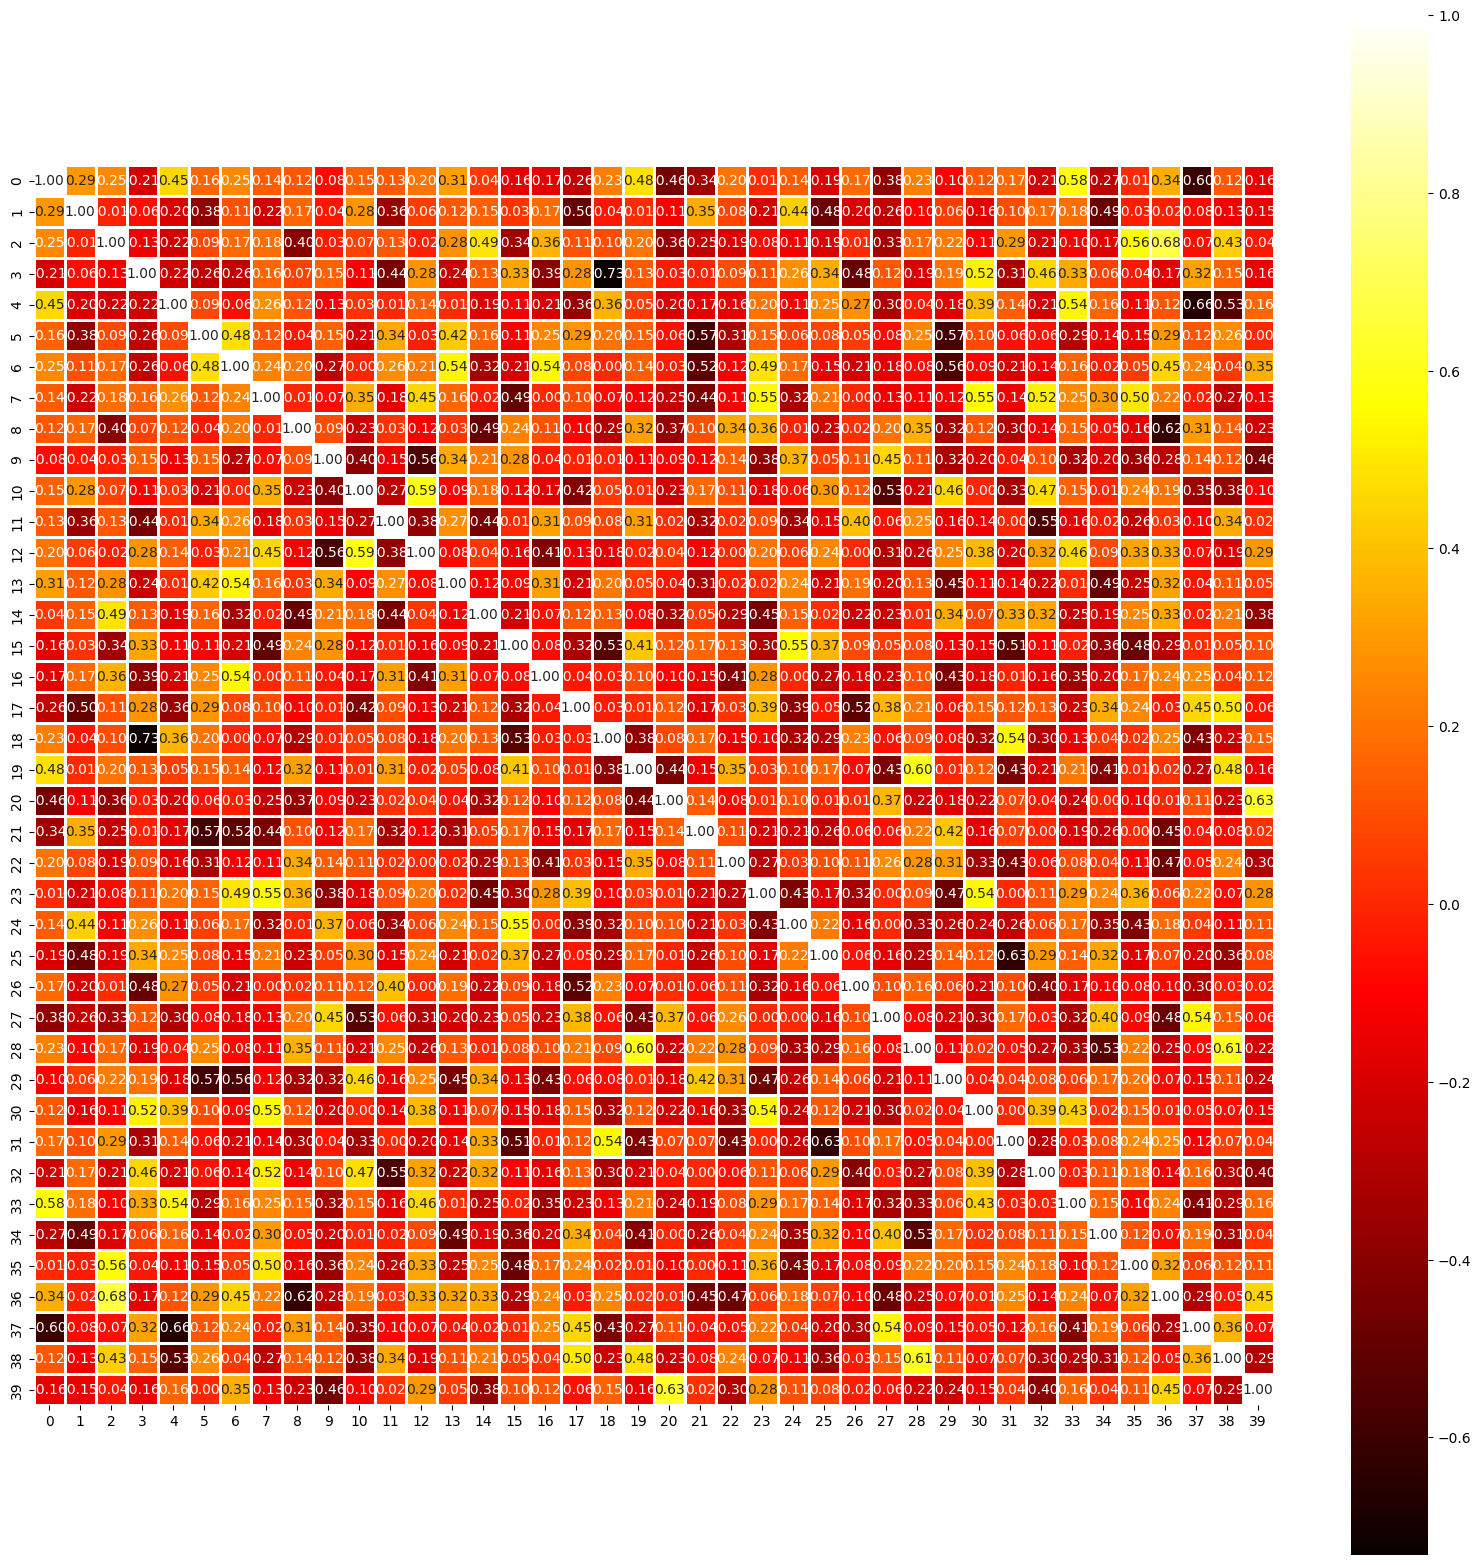

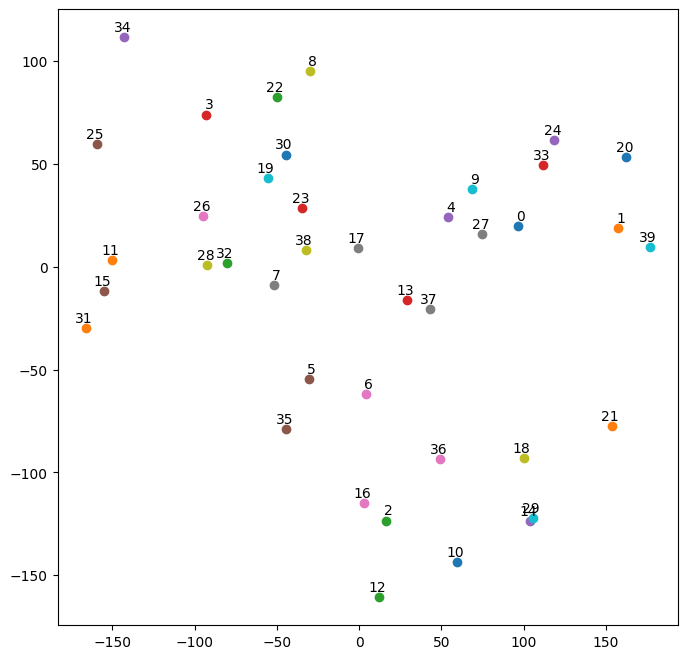

In [7]:
path = '/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin'
s = Similarity(path, 5, 3)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()

- Epoch = 5
- Embed size = 16
- Workers = 21

/users/student/pg/pg24/abhishek/.conda/envs/rnd/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


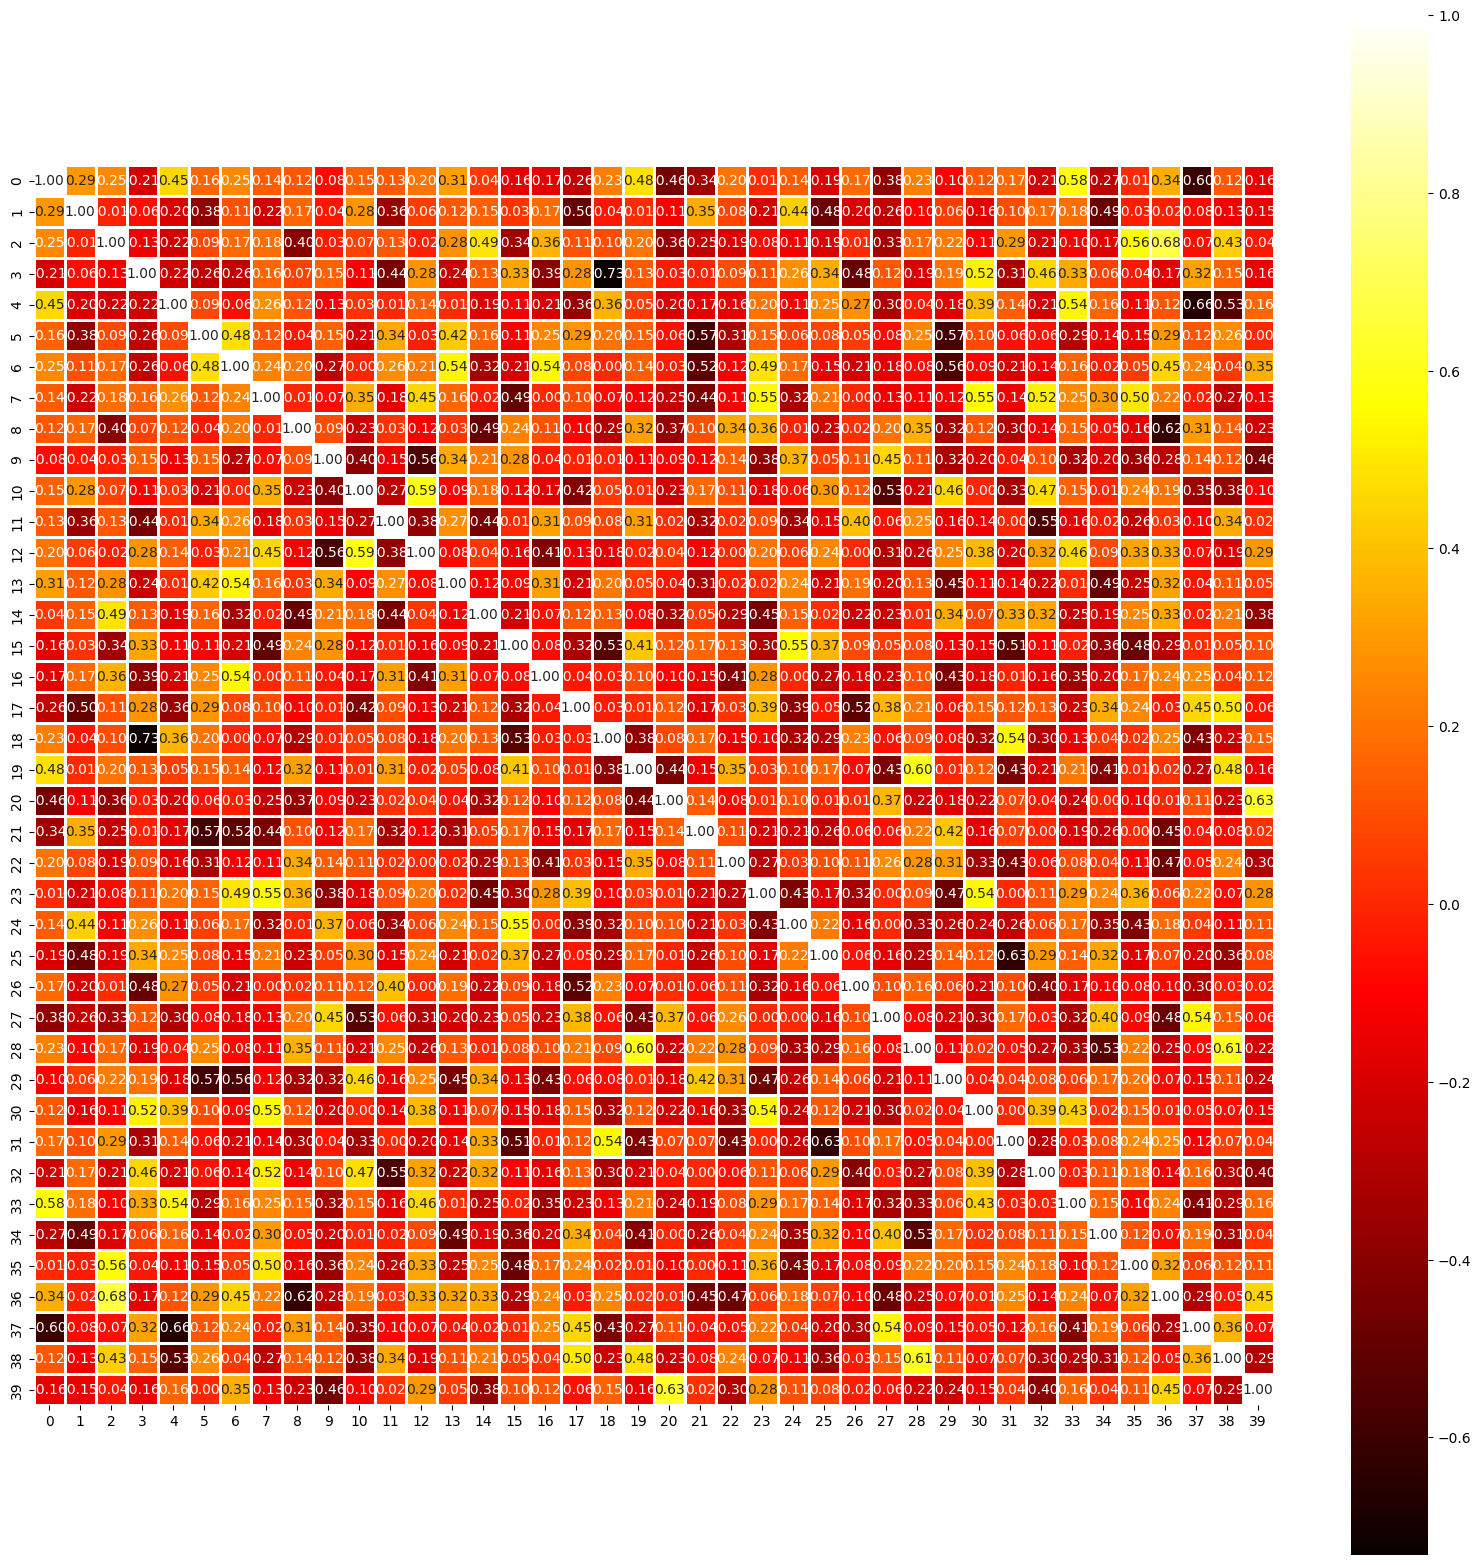

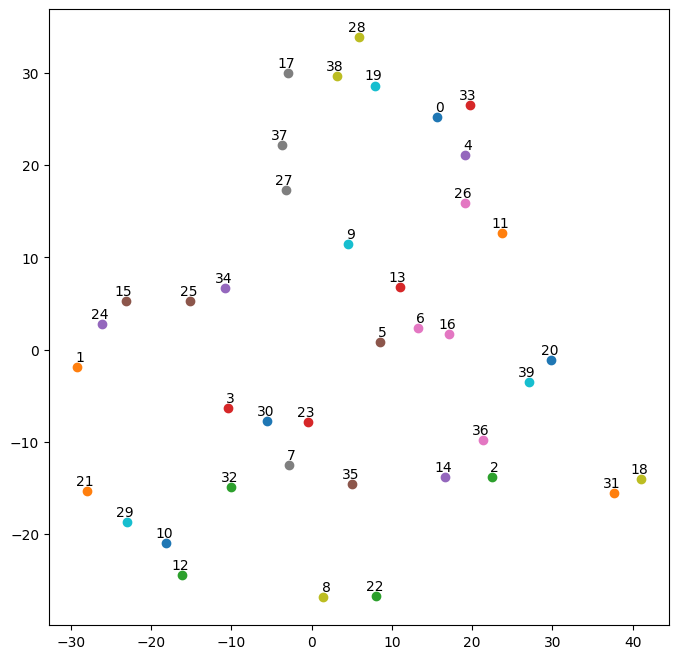

In [8]:
path = '/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin'
s = Similarity(path, 5, 2)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()

/users/student/pg/pg24/abhishek/.conda/envs/rnd/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


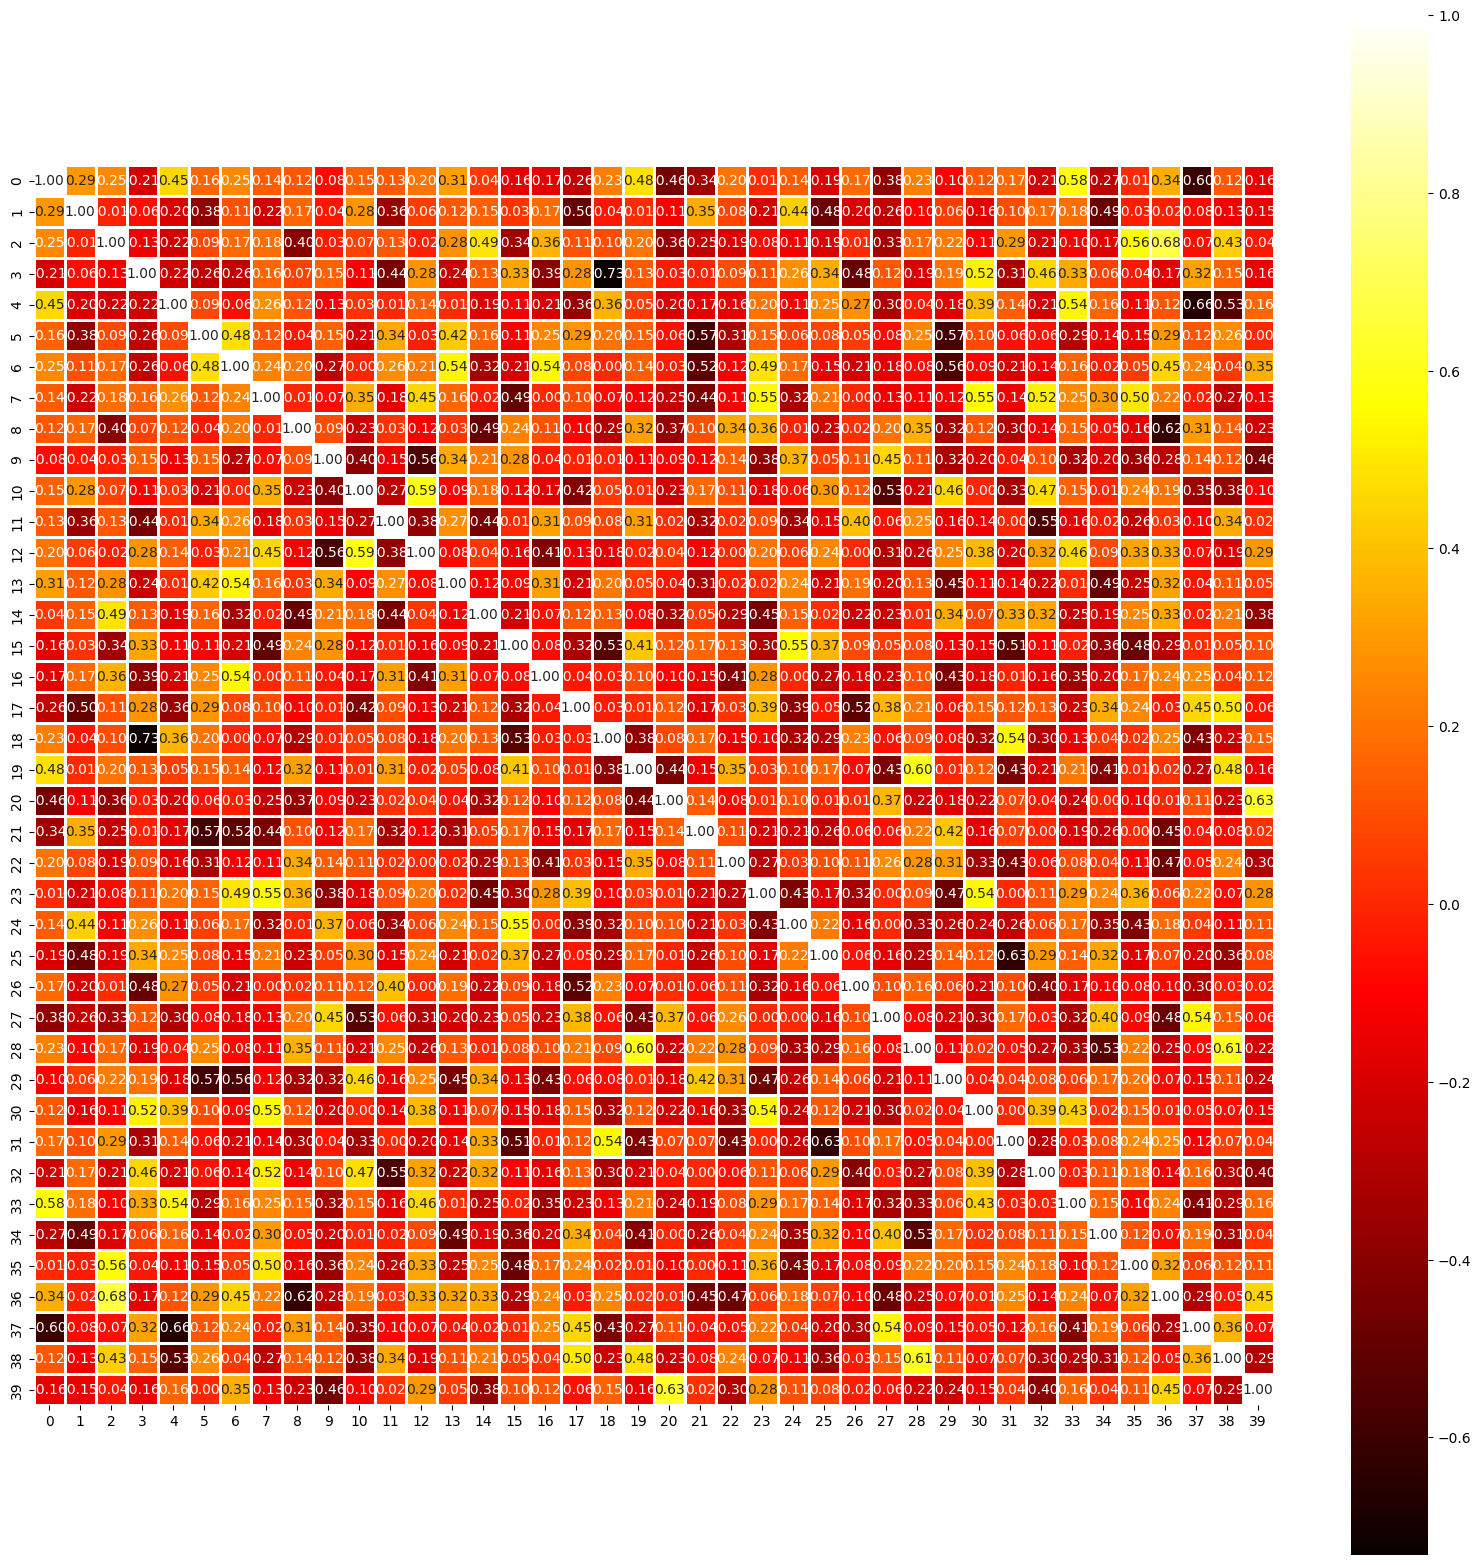

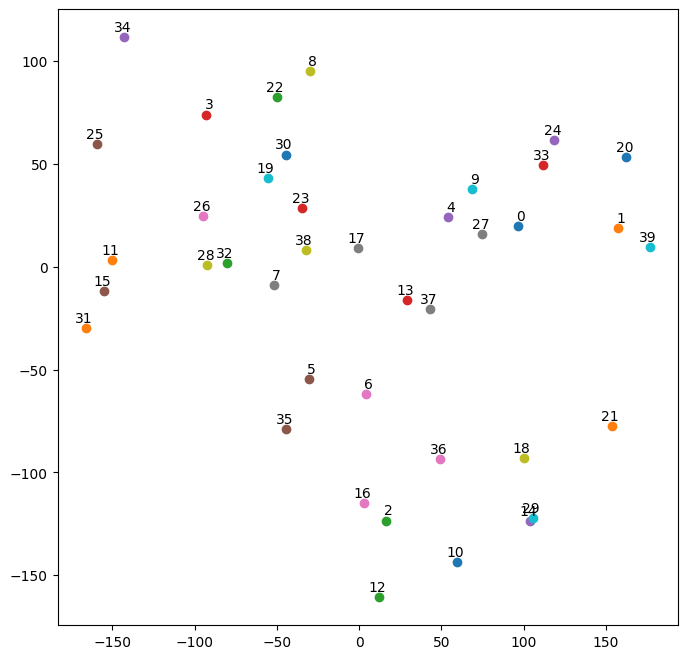

In [9]:
path = '/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin'
s = Similarity(path, 5, 3)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()

## K-Means Clustering to get Worker Groups

In [10]:
def ElbowMethod(path):
    checkpoint = torch.load(path, map_location='cpu')
    worker_embeddings = checkpoint['worker_embeddings.weight'].detach().cpu().numpy()
    K = worker_embeddings.shape[0]
    wcss = []
    k_range = []
    for k in range(1, K+1):
        k_range.append(k)
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(worker_embeddings)
        wcss.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='--')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()

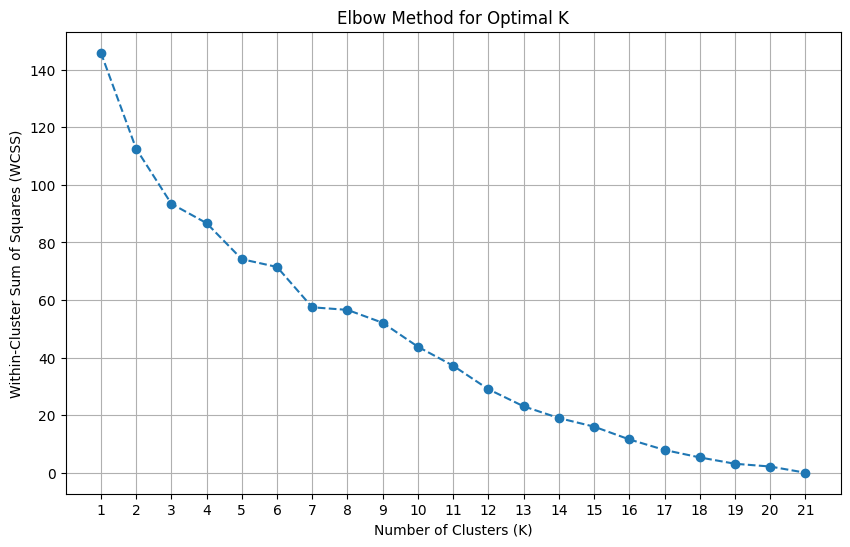

In [11]:
ElbowMethod(path='/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model/pytorch_model.bin')

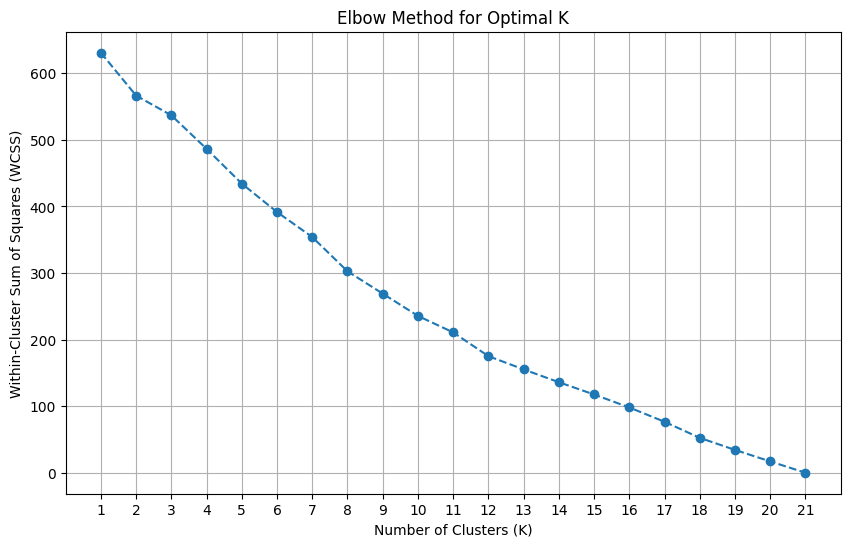

In [12]:
ElbowMethod(path='/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model_2/pytorch_model.bin')

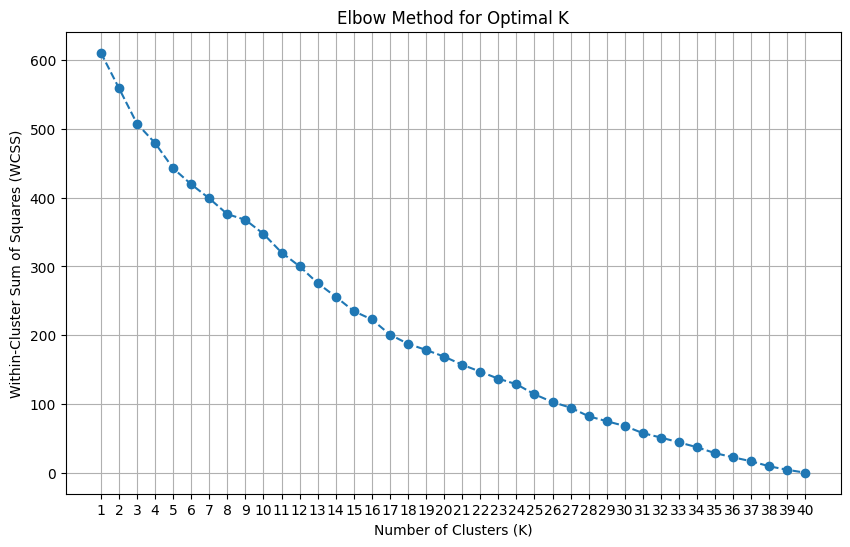

In [13]:
ElbowMethod(path='/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin')

/users/student/pg/pg24/abhishek/.conda/envs/rnd/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


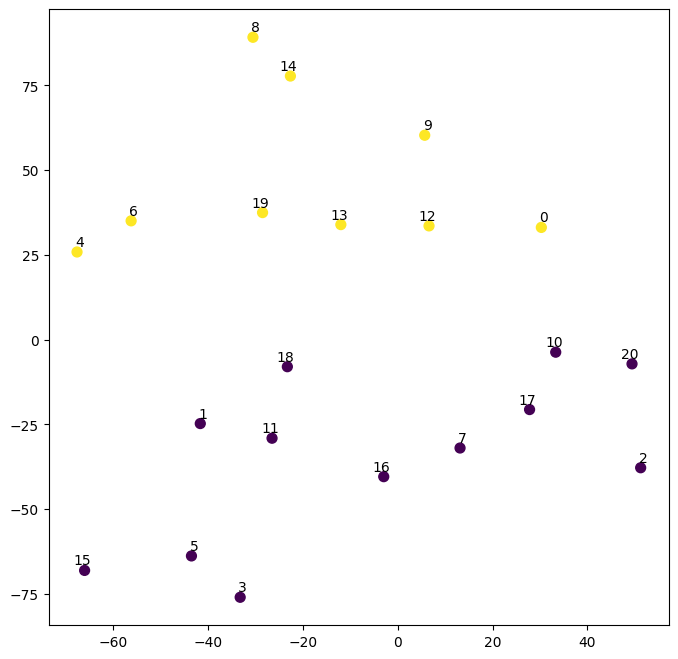

In [15]:
path = '/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model_2/pytorch_model.bin'
s = Similarity(path, 5, 2)
similarity, reduced_embeds, worker_ids = s.main()

kmeans = KMeans(n_clusters=2, random_state=42)
y_pred = kmeans.fit_predict(reduced_embeds)

x = []
y = []
for value in reduced_embeds:
    x.append(value[0])
    y.append(value[1])
    
plt.figure(figsize=(8, 8))
plt.scatter(x, y, c = y_pred, s = 50, cmap='viridis') 
for i in range(len(x)):
    plt.annotate(worker_ids[i], xy=(x[i], y[i]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
plt.show()

In [10]:
import torch.nn.functional as F
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

/users/student/pg/pg24/abhishek/.conda/envs/rnd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
MODEL_DIR = "/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model_G1"
DEVICE_ID = 0
DEVICE = torch.device(f"cuda:{DEVICE_ID}" if torch.cuda.is_available() else "cpu")

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForCausalLM.from_pretrained(MODEL_DIR, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model.to(DEVICE)
model.eval()

[2025-05-01 22:04:37,638] [INFO] [real_accelerator.py:158:get_accelerator] Setting ds_accelerator to cuda (auto detect)


GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 2048)
    (wpe): Embedding(2048, 2048)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPTNeoBlock(
        (ln_1): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (out_proj): Linear(in_features=2048, out_features=2048, bias=True)
          )
        )
        (ln_2): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=2048, out_features=8192, bias=True)
          (c_proj):

In [13]:
def get_logprob_score(prompt, completion):
    """Compute total log probability of completion given prompt."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(DEVICE)
    prompt_len = inputs.input_ids.shape[-1]

    full_input = tokenizer(prompt + completion, return_tensors="pt", truncation=True).to(DEVICE)
    with torch.no_grad():
        outputs = model(**full_input)
        logits = outputs.logits[:, :-1, :]
        labels = full_input.input_ids[:, 1:]

    log_probs = F.log_softmax(logits, dim=-1)
    completion_log_probs = log_probs[:, prompt_len - 1:, :]  # Removed the -1 as discussed
    target_tokens = labels[:, prompt_len - 1:]

    # Fix: truncate to common length if needed
    min_len = min(completion_log_probs.shape[1], target_tokens.shape[1])
    completion_log_probs = completion_log_probs[:, :min_len, :]
    target_tokens = target_tokens[:, :min_len]

    gathered = torch.gather(completion_log_probs, 2, target_tokens.unsqueeze(-1)).squeeze(-1)
    # Sum log probabilities and normalize by sequence length for a proper comparison
    total_log_prob = gathered.sum().item()
    if min_len <= 0:
        return total_log_prob
    return total_log_prob / min_len

In [16]:
from datasets import load_dataset
dataset = pd.read_csv("/users/student/pg/pg24/abhishek/Sarvesh_HCI/Test_Group_2.csv")

correct = 0
total = 0
# ignore_ind = [41780, 41783, 41784, 41827, 41828, 41829]
for i in tqdm(range(26657)):
    prompt = dataset["prompt"][i]
    chosen = dataset["Chosen"][i]
    rejected = dataset["Rejected"][i]
    
    # Generate a response with the current temperature
    #model_response = generate_with_temperature(prompt, temperature=temp)
    
    # Calculate scores
    chosen_score = get_logprob_score(prompt, chosen)
    rejected_score = get_logprob_score(prompt, rejected)
    
    if chosen_score > rejected_score:
        correct += 1
    total += 1

win_rate = correct / total
print(win_rate)

100%|██████████| 26657/26657 [11:50<00:00, 37.52it/s]

0.517162471395881


In [17]:
df = pd.read_csv("/users/student/pg/pg24/abhishek/Sarvesh_HCI/Train_small.csv")
allowed_worker_ids = [4, 6, 19, 13, 12, 0, 9, 14, 8]
new_df = df[df['worker'].isin(allowed_worker_ids)]
new_df.to_csv("Train_Group_1.csv")

In [18]:
df = pd.read_csv("/users/student/pg/pg24/abhishek/Sarvesh_HCI/Test_small.csv")
allowed_worker_ids = [4, 6, 19, 13, 12, 0, 9, 14, 8]
new_df = df[df['worker'].isin(allowed_worker_ids)]
new_df.to_csv("Test_Group_1.csv")

In [19]:
df = pd.read_csv("/users/student/pg/pg24/abhishek/Sarvesh_HCI/Train_small.csv")
allowed_worker_ids = [4, 6, 19, 13, 12, 0, 9, 14, 8]
new_df = df[~df['worker'].isin(allowed_worker_ids)]
new_df.to_csv("Train_Group_2.csv")

In [ ]:
df = pd.read_csv("/users/student/pg/pg24/abhishek/Sarvesh_HCI/Test_small.csv")
allowed_worker_ids = [4, 6, 19, 13, 12, 0, 9, 14, 8]
new_df = df[~df['worker'].isin(allowed_worker_ids)]
new_df.to_csv("Test_Group_2.csv")

In [22]:
df = pd.read_csv("/users/student/pg/pg24/abhishek/Sarvesh_HCI/Test_small.csv")
df["prompt_chosen"] = df["prompt"] + df["Chosen"]
df.head()

,Unnamed: 0,prompt,Chosen,Rejected,worker,prompt_chosen
0,0,SUBREDDIT: relationships\nTITLE: My [19M] girl...,Girlfriend is very jealous of my past partner...,My girlfriend is envious of my past relations...,20,SUBREDDIT: relationships\nTITLE: My [19M] girl...
1,1,SUBREDDIT: relationships\nTITLE: My [19M] girl...,Girlfriend is envious of my past intimate rel...,My girlfriend is envious of my past relations...,20,SUBREDDIT: relationships\nTITLE: My [19M] girl...
2,2,SUBREDDIT: relationships\nTITLE: My [19M] girl...,Girlfriend is very jealous of my past partner...,Girlfriend is jealous of my past relationship...,20,SUBREDDIT: relationships\nTITLE: My [19M] girl...
3,3,SUBREDDIT: relationships\nTITLE: My [19M] girl...,Girlfriend is very jealous of my past partner...,Girlfriend is envious of my past intimate rel...,20,SUBREDDIT: relationships\nTITLE: My [19M] girl...
4,4,SUBREDDIT: relationships\nTITLE: My [19M] girl...,Girlfriend is envious of my past intimate rel...,Girlfriend is jealous of my past relationship...,20,SUBREDDIT: relationships\nTITLE: My [19M] girl...
